# DATS 2102 Midterm Project - Safety on the Railroad


---
title: "DATS 2102 Midterm Submission"
author: Anthony Shustef
date: 'March 2, 2025'
format:
    html:
        code-fold: false
        toc: true
        toc-depth: 3
        toc-title: "Table of Contents"
jupyter: python3
---

### Overview of Dataset

This dataset, **railroad.csv**, focuses on the evaluation of major accidents and similar incidents along rights-of-way of major Class I freight railroads to compare the amount of incidents for each railroad and the magnitude of the incident. The following visualizations are based upon **railroad.csv**.

*This dataset was provided by the Federal Railroad Administration (FRA).*

## Research Questions for Analysis

1. Which states have the largest amounts of railroad accidents?
 2. What is the distribution of equipment damage costs among a subset of predetermined railroads?
 3. Which year has the largest amount of railroad accidents? Are there any statistical outliers?
4. Does weather condition or time of day impact the amount of railroad accidents?
5. Which division of railroad trackage has the largest amounts of accidents?


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

railroad = pd.read_csv('Rail_Equipment_Accident_Incident_Data__Form_54_.csv')

railroad.head()

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,...,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
0,UP,Union Pacific Railroad Company,1975,1275NP201,https://safetydata.fra.dot.gov/Officeofsafety/...,75,12,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,NaN
1,SOO,SOO Line Railroad Company,1999,154107,https://safetydata.fra.dot.gov/Officeofsafety/...,99,9,WC,WISCONSIN CENTRAL LTD.,G4606,...,CANADIAN PACIFIC KANSAS CITY,Not Assigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN
2,CSX,CSX Transportation,2007,000028424,https://safetydata.fra.dot.gov/Officeofsafety/...,7,1,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
3,CSX,CSX Transportation,2007,000035140,https://safetydata.fra.dot.gov/Officeofsafety/...,7,4,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
4,CSX,CSX Transportation,2007,000032761,https://safetydata.fra.dot.gov/Officeofsafety/...,7,5,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)


In [2]:
railroad_FEC = railroad[railroad["Reporting Railroad Code"] == "FEC"]
railroad_FEC

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,...,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
152,FEC,Florida East Coast Railway Company,2017,D35060717,https://safetydata.fra.dot.gov/Officeofsafety/...,17,6,NaN,NaN,NaN,...,Florida East Coast Railway Company,Railroad Acquisition Holdings,Class II,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Yes,POINT (-80.078156 26.764844)
341,FEC,Florida East Coast Railway Company,2007,D71082107,https://safetydata.fra.dot.gov/Officeofsafety/...,7,8,NaN,NaN,NaN,...,Florida East Coast Railway Company,Railroad Acquisition Holdings,Class II,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Yes,POINT (0 0)
454,FEC,Florida East Coast Railway Company,2007,D98110207,https://safetydata.fra.dot.gov/Officeofsafety/...,7,11,NS,Norfolk Southern Railway Company,030811,...,Florida East Coast Railway Company,Railroad Acquisition Holdings,Class II,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Yes,POINT (0 0)
789,FEC,Florida East Coast Railway Company,1997,65338JU7,https://safetydata.fra.dot.gov/Officeofsafety/...,97,7,NaN,NaN,NaN,...,Florida East Coast Railway Company,Railroad Acquisition Holdings,Class II,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Yes,NaN
904,FEC,Florida East Coast Railway Company,1997,65337JU7,https://safetydata.fra.dot.gov/Officeofsafety/...,97,7,NaN,NaN,NaN,...,Florida East Coast Railway Company,Railroad Acquisition Holdings,Class II,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Yes,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221865,FEC,Florida East Coast Railway Company,2004,X29111004,https://safetydata.fra.dot.gov/Officeofsafety/...,4,11,NaN,NaN,NaN,...,Florida East Coast Railway Company,Railroad Acquisition Holdings,Class II,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Yes,POINT (0 0)
222196,FEC,Florida East Coast Railway Company,2005,D40032105,https://safetydata.fra.dot.gov/Officeofsafety/...,5,3,NaN,NaN,NaN,...,Florida East Coast Railway Company,Railroad Acquisition Holdings,Class II,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Yes,POINT (0 0)
222287,FEC,Florida East Coast Railway Company,2004,D67A071604,https://safetydata.fra.dot.gov/Officeofsafety/...,4,7,NaN,NaN,NaN,...,Florida East Coast Railway Company,Railroad Acquisition Holdings,Class II,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Yes,POINT (0 0)
222333,FEC,Florida East Coast Railway Company,2005,D12013105,https://safetydata.fra.dot.gov/Officeofsafety/...,5,1,NaN,NaN,NaN,...,Florida East Coast Railway Company,Railroad Acquisition Holdings,Class II,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Yes,POINT (0 0)


## Preparation for Visualization

In this section, I prepared the dataset for visualization by filtering the dataset, aggregating, joining, and other operations to clean the data.

In [17]:
codes = railroad["Reporting Railroad Code"].dropna().unique()[:5]
df = railroad[railroad["Reporting Railroad Code"].isin(codes)].copy()
areas = pd.read_csv("state-areas.csv")
areas["states_upper"] = areas["state"].str.upper()

df["Equipment Damage Cost"] = pd.to_numeric(df["Equipment Damage Cost"], errors="coerce")
df["Total Persons Injured"] = pd.to_numeric(df["Total Persons Injured"], errors="coerce")
df_filtered = df[(df["Equipment Damage Cost"] < 40000) & (df["Equipment Damage Cost"] >= 0) & (df["Train Speed"] <= 50)]

summary = (
df.groupby("Reporting Railroad Code", as_index=False)["Equipment Damage Cost"]
.mean()
.dropna()
.sort_values("Equipment Damage Cost")
)

summary_passengers = (
df.groupby("Reporting Railroad Code", as_index=False)["Total Persons Injured"]
.mean()
.dropna()
.sort_values("Total Persons Injured")
)
summary.head()
areas.head()

,state,area (sq. mi),states_upper
0,Alabama,52423,ALABAMA
1,Alaska,656425,ALASKA
2,Arizona,114006,ARIZONA
3,Arkansas,53182,ARKANSAS
4,California,163707,CALIFORNIA


In [39]:
#state_accident_count = df.groupby(by="State Name").size().to_frame("Number of Accidents")
state_accident_count = df.pivot_table(index="State Name", values="Milepost", aggfunc="count").rename(columns={"Milepost":"Number of Accidents"})

state_joined = state_accident_count.merge(
    areas,
    left_on="State Name", right_on="states_upper", how="left", validate="1:1"
)

state_joined["Accidents/Square Mile"] = state_joined["Number of Accidents"]/state_joined["area (sq. mi)"]

state_joined

,Number of Accidents,state,area (sq. mi),states_upper,Accidents/Square Mile
0,1022,Alabama,52423,ALABAMA,0.019495
1,611,Arizona,114006,ARIZONA,0.005359
2,2320,Arkansas,53182,ARKANSAS,0.043624
3,3922,California,163707,CALIFORNIA,0.023957
4,1264,Colorado,104100,COLORADO,0.012142
5,10,Connecticut,5544,CONNECTICUT,0.001804
6,37,Delaware,1954,DELAWARE,0.018936
7,25,District of Columbia,68,DISTRICT OF COLUMBIA,0.367647
8,1076,Florida,65758,FLORIDA,0.016363
9,1739,Georgia,59441,GEORGIA,0.029256


## Exhibit A: Which State Has the Largest Number of Railroad Accidents per Square Mile?

This short section is meant to answer the question as to which state tends to have the largest amount of railroad accidents per square mile. This question is answered with a simple bar chart using 5 states with the highest amount of accidents in the descending order.

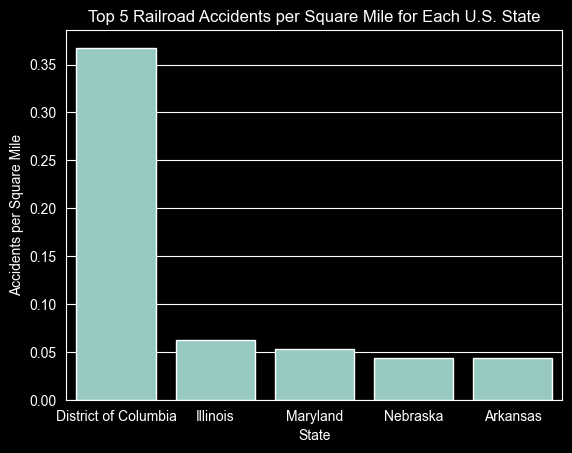

In [40]:
# Matplotlib bar chart
state_joined_sorted = state_joined.sort_values(by="Accidents/Square Mile", ascending=False)[:5]
sns.barplot(data=state_joined_sorted, x="state", y="Accidents/Square Mile", errorbar=None)
plt.title("Top 5 Railroad Accidents per Square Mile for Each U.S. State")
plt.xlabel("State"); plt.ylabel("Accidents per Square Mile")
plt.show()

## Exhibit B: Which Railroads Have the Highest Equipment Damage Costs?

This  section is meant to answer the question as to which railroad tends to incur the highest amount of equipment damage costs due to accidents and other similar incidents. This question is answered using distribution plots such as boxplots and violin plots as well as bar graphs.

Text(1.8, 4, '')

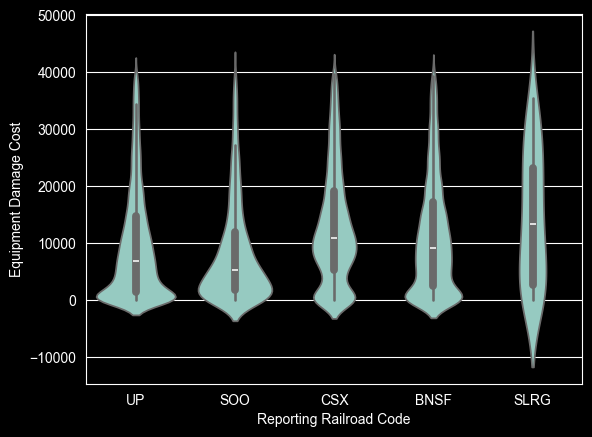

In [4]:
# REVISED Violin Plot
sns.violinplot(data=df_filtered, x='Reporting Railroad Code', y='Equipment Damage Cost')
plt.text(x=1.8, y=4, s="", fontsize=12, color='white', weight='bold', bbox=dict(facecolor='black', alpha=0.5))

Text(1.8, 4, '')

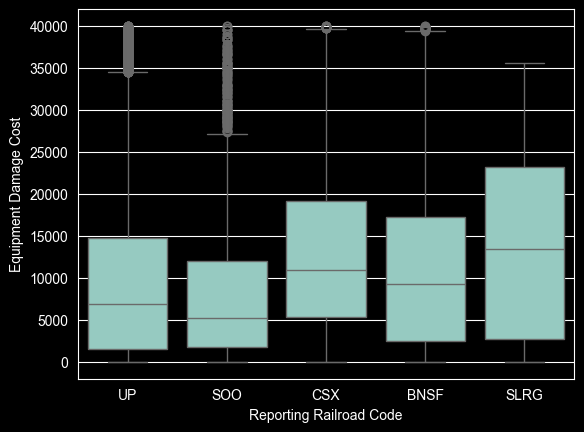

In [5]:
# Boxplot
sns.boxplot(data=df_filtered, x='Reporting Railroad Code', y='Equipment Damage Cost')
plt.text(x=1.8, y=4, s="", fontsize=12, color='white', weight='bold', bbox=dict(facecolor='black', alpha=0.5))

Text(3.5, -15000.5, 'Lowest cost')

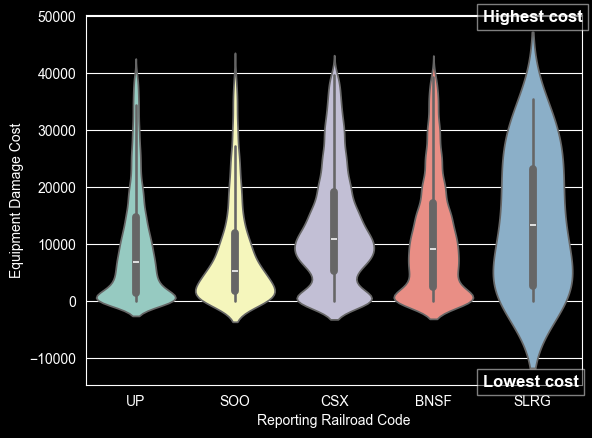

In [8]:
# REVISED Violin Plot
sns.violinplot(data=df_filtered, x='Reporting Railroad Code', y='Equipment Damage Cost', hue='Reporting Railroad Code')
plt.text(x=1.8, y=4, s="", fontsize=12, color='white', weight='bold', bbox=dict(facecolor='black', alpha=0.5))

plt.text(x=3.5, y=49000.5, s="Highest cost", fontsize=12, color='white', weight='bold', bbox=dict(facecolor='black', alpha=0.5))

plt.text(x=3.5, y=-15000.5, s="Lowest cost", fontsize=12, color='white', weight='bold', bbox=dict(facecolor='black', alpha=0.5))

In [9]:
df

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,...,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
0,UP,Union Pacific Railroad Company,1975,1275NP201,https://safetydata.fra.dot.gov/Officeofsafety/...,75,12,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,NaN
1,SOO,SOO Line Railroad Company,1999,154107,https://safetydata.fra.dot.gov/Officeofsafety/...,99,9,WC,WISCONSIN CENTRAL LTD.,G4606,...,CANADIAN PACIFIC KANSAS CITY,Not Assigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN
2,CSX,CSX Transportation,2007,000028424,https://safetydata.fra.dot.gov/Officeofsafety/...,7,1,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
3,CSX,CSX Transportation,2007,000035140,https://safetydata.fra.dot.gov/Officeofsafety/...,7,4,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
4,CSX,CSX Transportation,2007,000032761,https://safetydata.fra.dot.gov/Officeofsafety/...,7,5,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223686,BNSF,BNSF Railway Company,2023,NW0323113,https://safetydata.fra.dot.gov/Officeofsafety/...,23,3,NaN,NaN,NaN,...,BNSF Railway Company,BNSF Railway Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (-122.518197 48.459529)
223687,UP,Union Pacific Railroad Company,2020,0220GP005,https://safetydata.fra.dot.gov/Officeofsafety/...,20,2,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (-104.818456 41.127445)
223688,BNSF,BNSF Railway Company,2011,NW0411106,https://safetydata.fra.dot.gov/Officeofsafety/...,11,4,NaN,NaN,NaN,...,BNSF Railway Company,BNSF Railway Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
223689,UP,Union Pacific Railroad Company,2015,0115NP051,https://safetydata.fra.dot.gov/Officeofsafety/...,15,1,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (-104.911355 42.761856)


In [10]:
railroad = pd.read_csv('Rail_Equipment_Accident_Incident_Data__Form_54_.csv')
#codes = railroad["Reporting Railroad Code"].dropna().unique()[:10]
codes = ['BNSF', 'UP', 'CSX', 'KCS', 'CP', 'CN', 'NS', 'ATK', 'FEC', 'SCAX']
df_new = railroad[railroad["Reporting Railroad Code"].isin(codes)].copy()

In [11]:
df_new

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,...,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
0,UP,Union Pacific Railroad Company,1975,1275NP201,https://safetydata.fra.dot.gov/Officeofsafety/...,75,12,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,NaN
2,CSX,CSX Transportation,2007,000028424,https://safetydata.fra.dot.gov/Officeofsafety/...,7,1,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
3,CSX,CSX Transportation,2007,000035140,https://safetydata.fra.dot.gov/Officeofsafety/...,7,4,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
4,CSX,CSX Transportation,2007,000032761,https://safetydata.fra.dot.gov/Officeofsafety/...,7,5,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
5,CSX,CSX Transportation,2006,000019091,https://safetydata.fra.dot.gov/Officeofsafety/...,6,1,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223686,BNSF,BNSF Railway Company,2023,NW0323113,https://safetydata.fra.dot.gov/Officeofsafety/...,23,3,NaN,NaN,NaN,...,BNSF Railway Company,BNSF Railway Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (-122.518197 48.459529)
223687,UP,Union Pacific Railroad Company,2020,0220GP005,https://safetydata.fra.dot.gov/Officeofsafety/...,20,2,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (-104.818456 41.127445)
223688,BNSF,BNSF Railway Company,2011,NW0411106,https://safetydata.fra.dot.gov/Officeofsafety/...,11,4,NaN,NaN,NaN,...,BNSF Railway Company,BNSF Railway Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (0 0)
223689,UP,Union Pacific Railroad Company,2015,0115NP051,https://safetydata.fra.dot.gov/Officeofsafety/...,15,1,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (-104.911355 42.761856)


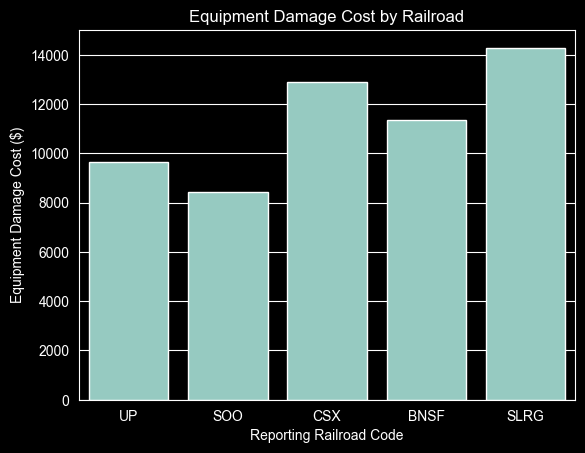

In [7]:
# Matplotlib bar chart
sns.barplot(data=df_filtered, x="Reporting Railroad Code", y="Equipment Damage Cost", errorbar=None)
plt.title("Equipment Damage Cost by Railroad")
plt.xlabel("Reporting Railroad Code"); plt.ylabel("Equipment Damage Cost ($)")
plt.show()

<Axes: xlabel='Equipment Damage Cost', ylabel='Reporting Railroad Code'>

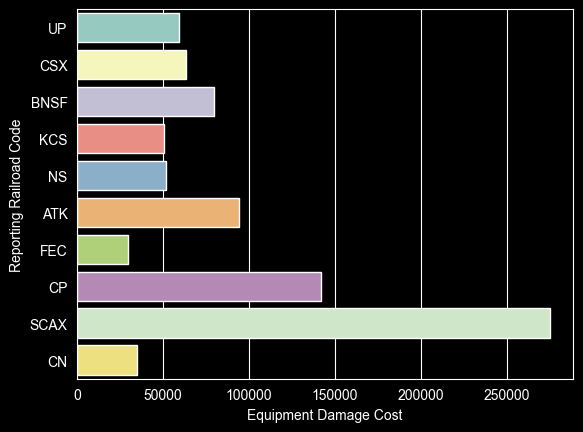

In [12]:
sns.barplot(df_new, x="Equipment Damage Cost", y="Reporting Railroad Code", hue='Reporting Railroad Code', legend=False, errorbar=None)

## Exhibit C: Change in Equipment Damage Costs Over Time

This short section is meant to evaluate the change in equipment damage costs over a predetermined period of time for different railroads. This is done using a slope chart which compares the equipment damage costs over a ten year period.

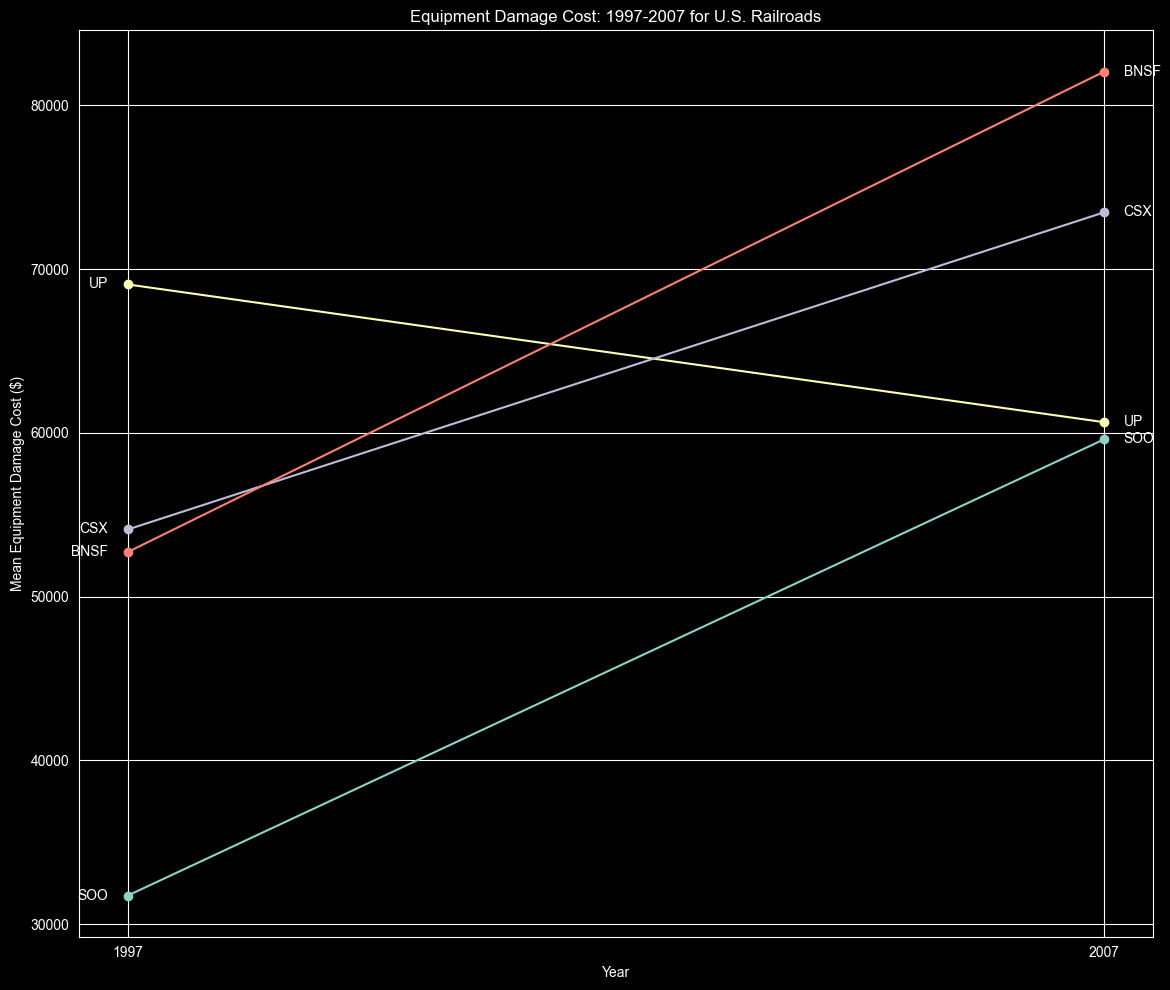

In [6]:
df["Equipment Damage Cost"] = pd.to_numeric(df["Equipment Damage Cost"], errors="coerce")

top_codes = df["Reporting Railroad Code"].value_counts().head(10).index
#df = df[df["Reporting Railroad Code"].isin(top_codes)]

df_2years = df[df["Year"].isin([1997, 2007])]

slope = (df_2years
         .groupby(["Reporting Railroad Code", "Year"])["Equipment Damage Cost"]
         .mean()
         .unstack()
         .dropna())

slope.columns = ["1997", "2007"]

slope = slope.sort_values("2007")

plt.figure(figsize=(12, 10))
plt.subplots_adjust(left=0.60)


for code, row in slope.iterrows():
    plt.plot([0, 1], [row["1997"], row["2007"]], marker="o")
    plt.text(-0.02, row["1997"], code, ha="right", va="center")
    plt.text(1.02, row["2007"], code, ha="left", va="center")

plt.xticks([0, 1], ["1997", "2007"])
plt.xlabel("Year")
plt.ylabel("Mean Equipment Damage Cost ($)")
plt.title("Equipment Damage Cost: 1997-2007 for U.S. Railroads")
plt.tight_layout()

plt.show()

## Written Narrative

As a Data Science major with a focus in geospatial analysis and transportation studies, this was a
unique opportunity to conduct an analysis based on rail transportation. Specifically, I intended to study
the safety metrics for each of the major railroads of the United States within the last half-century.

There were many directions in which I intended to approach this analysis, because I could, for example, compare injury rates during accidents for each railroad, or perhaps compare costs for equipment damages due to accidents for each railroad. In the end, I chose the latter because it provided me with a greater ability to glean meaningful insights due to the fact that there was significantly more variation for this variable.

Due to the fact that not doing so would require massive amounts of memory due to the sheer amount of railroads in the dataset, only ten railroads were selected for analysis. For most graphs, these ten railroads were selected arbitrarily (the first ten railroads in the dataset), while, for others, these were selected manually for more meaningful insights.

I preferred using colors for some of the visualizations so as to better distinguish the data for specific railroads. I also used the railroad codes rather than the full names of the railroads so as to not clutter the graphs.

Overall, I find the insights that I gleaned from the data incredibly intriguing because it answers many of the questions I pondered about the operations of each of the major railroads in the U.S. and allows me to engage with my knowledge of railroad operations to better interpret these results.